In [ ]:
#pip install scikit-learn
#pip install jupyter
#pip install widgetsnbextension

In [6]:
import io
import os
import glob
import pickle
from PIL import Image
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
from scipy import signal
import torch
import torchvision.transforms.functional as TF
import sklearn
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
#from sklearn import linear_model
#from sklearn import 

#  import precision_recall_curve
# import average_precision_score
#from sklearn.linear_model import LogisticRegression

DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"
DINOV3_LOCATION = "/home/levandov/dinov3/dinov3"

# examples of available DINOv3 models:
#MODEL_DINOV3_VITS = "dinov3_vits16"
#MODEL_DINOV3_VITSP = "dinov3_vits16plus"
#MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
#MODEL_DINOV3_VITHP = "dinov3_vith16plus"
#MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITL

REPO_DIR = "/home/levandov/dinov3/dinov3"
# downloaded into /home/levandov/.cache/torch/hub/checkpoints"

# check also:

# DINOv3 ViT models pretrained on web images
# dinov3_vitl16 = torch.hub.load(REPO_DIR, 'dinov3_vitl16', source='local', weights=<CHECKPOINT/URL/OR/PATH>)
# DINOv3 ViT models pretrained on satellite imagery
# DINOv3 ViT SAT-493M
# dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth sits among links from META

model = torch.hub.load(REPO_DIR, 'dinov3_vitl16', source='local',) 
#weights=<CHECKPOINT/URL/OR/PATH>

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=MODEL_NAME,
    source="local" if DINOV3_LOCATION != DINOV3_GITHUB_LOCATION else "github",
)
model.cuda()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm)

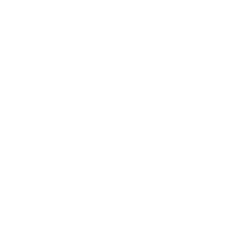

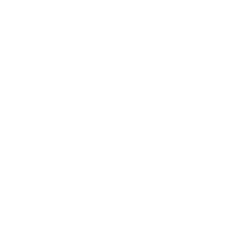

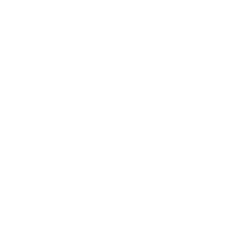

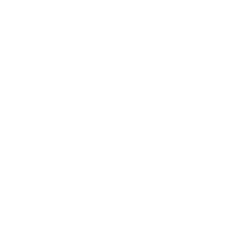

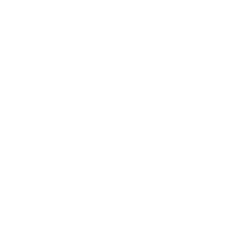

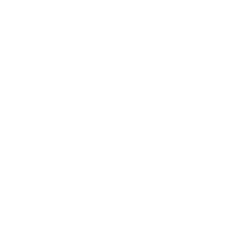

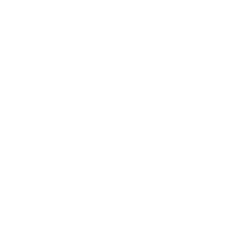

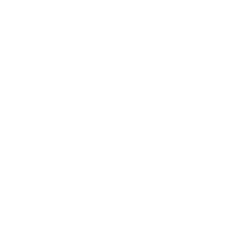

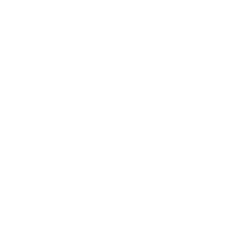

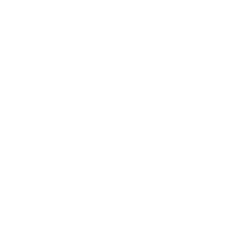

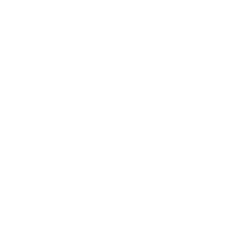

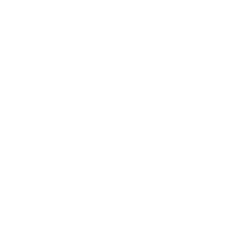

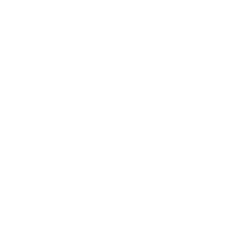

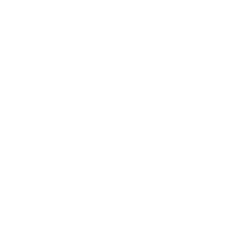

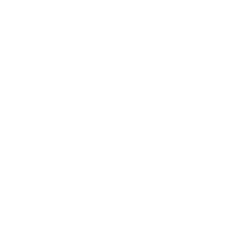

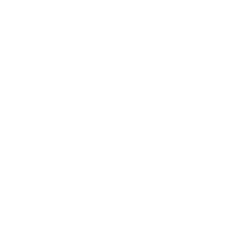

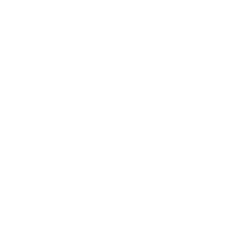

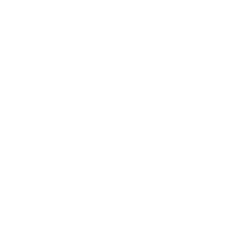

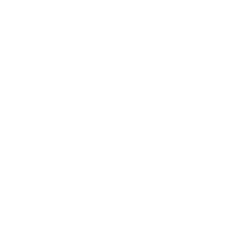

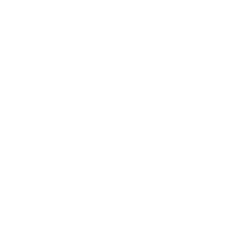

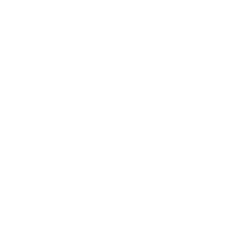

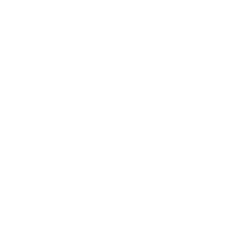

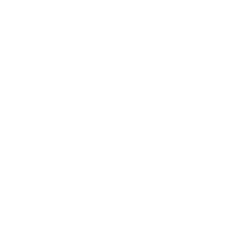

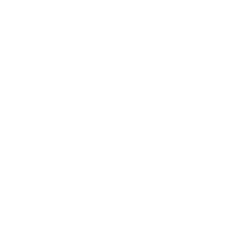

images: 24
labels: 24
Loaded 24 images and labels


In [7]:
# load the data
DPATH = "/home/levandov/dv"
train_images_dir = DPATH + "/images/"
train_labels_dir = DPATH + "/labels/"

images = []
for member in sorted(glob.glob(train_images_dir+"*.png")):
#  print(member)
  image = Image.open(member)
  plt.figure(figsize=(4, 4), dpi=75)
  plt.axis('off')
  plt.show()
  images.append(image)
print("images: "+str(len(images)))
labels = []
for member in sorted(glob.glob(train_labels_dir+"*.png")):
  label = Image.open(member)
#  plt.show()
  labels.append(label)
print("labels: "+str(len(labels)))

n_images = len(images)
assert n_images == len(labels), f"{len(images)=}, {len(labels)=}"

print(f"Loaded {n_images} images and labels")

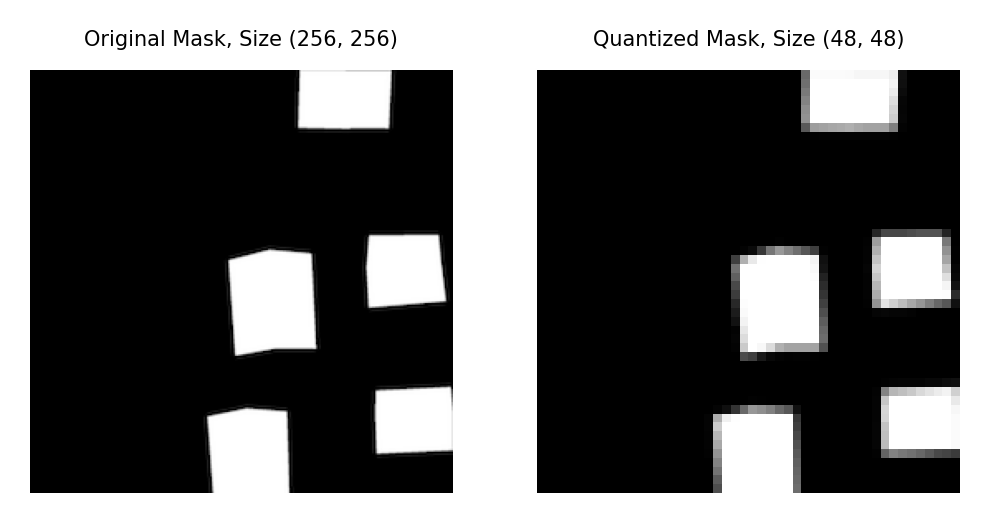

In [8]:
#Building Per-Patch Label Map
PATCH_SIZE = 16
IMAGE_SIZE = 768
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

mask_0 = labels[0].split()[-1]
mask_0_resized = resize_transform(mask_0)
with torch.no_grad():
    mask_0_quantized = patch_quant_filter(mask_0_resized).squeeze().detach().cpu()

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(mask_0,cmap='gray')
plt.axis('off')
plt.title(f"Original Mask, Size {mask_0.size}", fontsize=5)
plt.subplot(1, 2, 2)
plt.imshow(mask_0_quantized,cmap='gray')
plt.axis('off')
plt.title(f"Quantized Mask, Size {tuple(mask_0_quantized.shape)}", fontsize=5)
plt.show()

In [9]:
# most work is done here
xs = []
ys = []
image_index = []

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
# MODEL_TO_NUM_LAYERS[MODEL_NAME]
# resolved manually for my case dinov3_vitl16 gives 
n_layers = 24

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        for i in tqdm(range(n_images), desc="Processing images"):
            # Loading the ground truth
            mask_i = labels[i].split()[-1]
            mask_i_resized = resize_transform(mask_i)
            mask_i_quantized = patch_quant_filter(mask_i_resized).squeeze().view(-1).detach().cpu()
            ys.append(mask_i_quantized)
            # Loading the image data 
            image_i = images[i].convert('RGB')
            image_i_resized = resize_transform(image_i)
            image_i_resized = TF.normalize(image_i_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_i_resized = image_i_resized.unsqueeze(0).cuda()

            feats = model.get_intermediate_layers(image_i_resized, n=range(n_layers), reshape=True, norm=True)
            dim = feats[-1].shape[1]
            xs.append(feats[-1].squeeze().view(dim, -1).permute(1,0).detach().cpu())

            image_index.append(i * torch.ones(ys[-1].shape))

# Concatenate all lists into torch tensors 
xs = torch.cat(xs)
ys = torch.cat(ys)
image_index = torch.cat(image_index)

# keeping only the patches that have clear positive or negative label
idx = (ys < 0.01) | (ys > 0.99)
xs = xs[idx]
ys = ys[idx]
image_index = image_index[idx]

print("Orig matrix of size : ", xs.shape)
print("Label matrix of size : ", ys.shape)

Processing images: 100%|███████████████████████████████████████████████████████████████████████████| 24/24 [23:21<00:00, 58.38s/it]


Orig matrix of size :  torch.Size([50648, 1024])
Label matrix of size :  torch.Size([50648])


validation using image_01.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

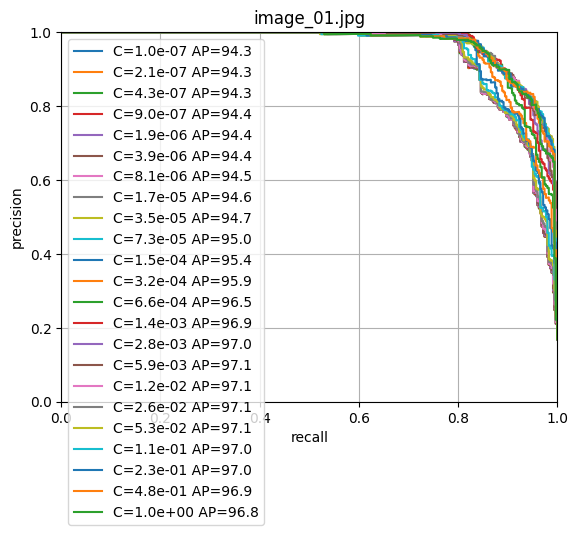

validation using image_02.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

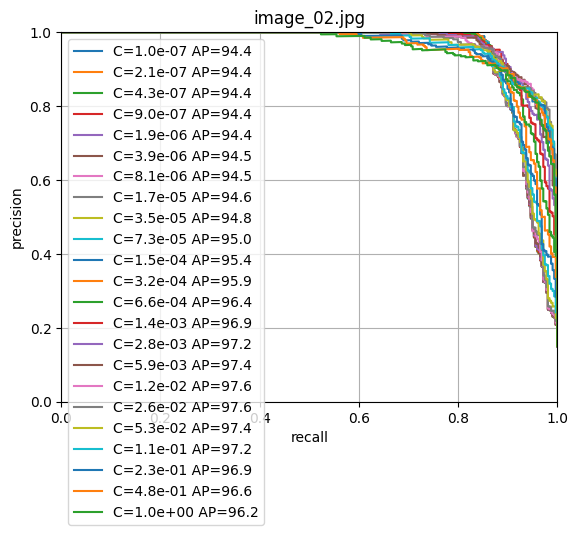

validation using image_03.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

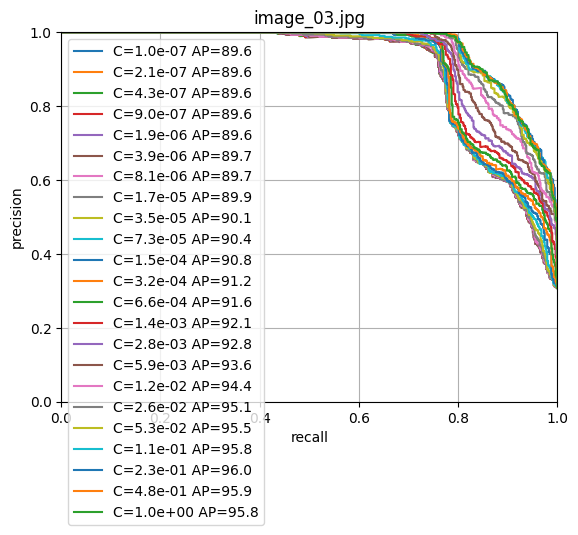

validation using image_04.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

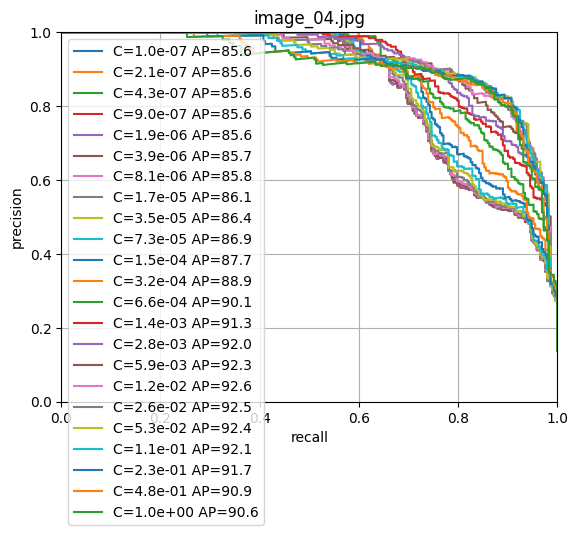

validation using image_05.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

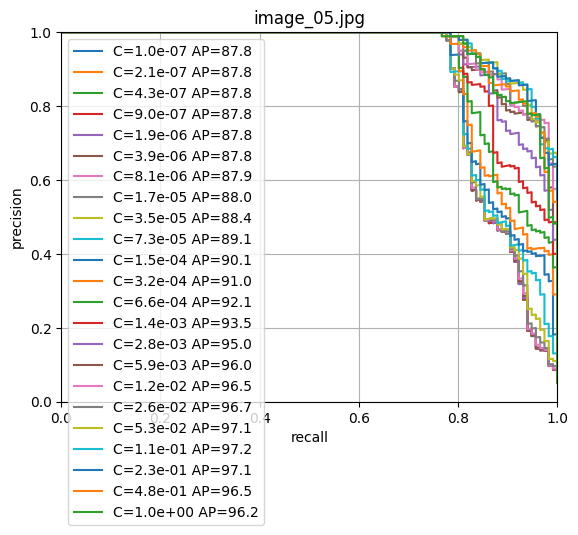

validation using image_06.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

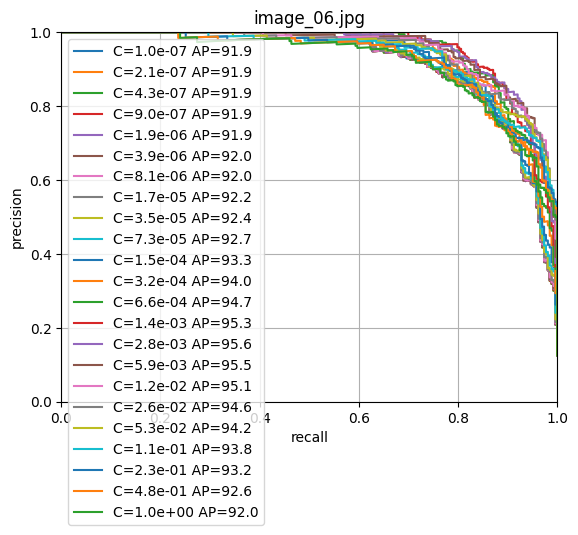

validation using image_07.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

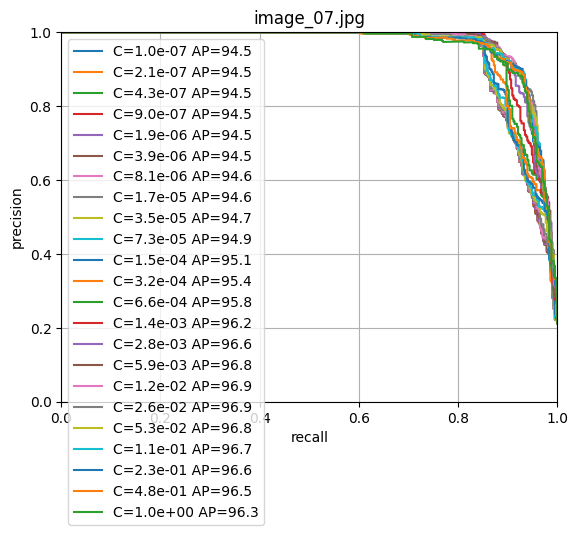

validation using image_08.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

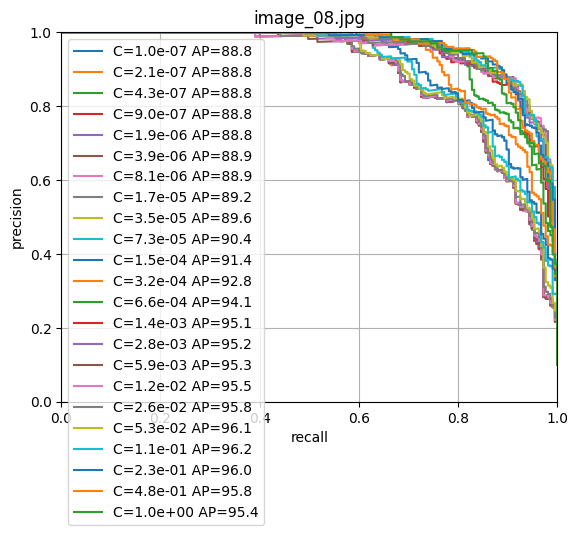

validation using image_09.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

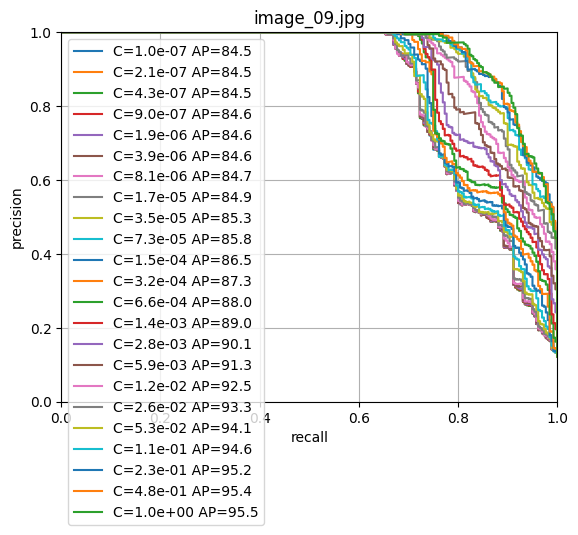

validation using image_10.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

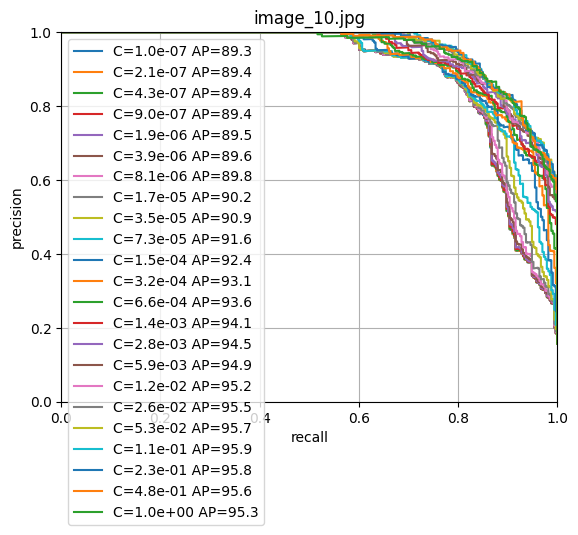

validation using image_11.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

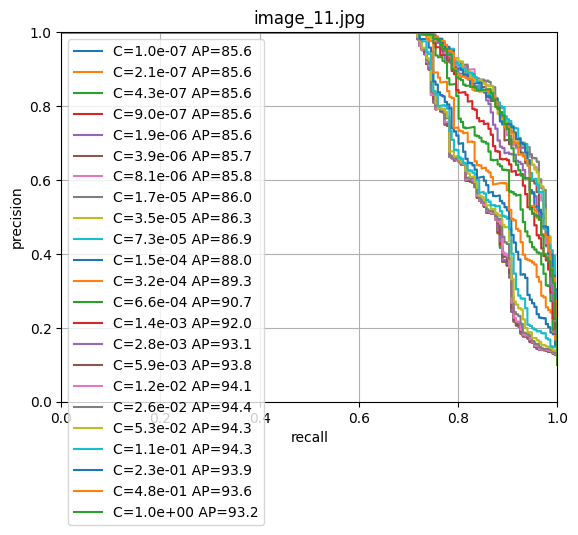

validation using image_12.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

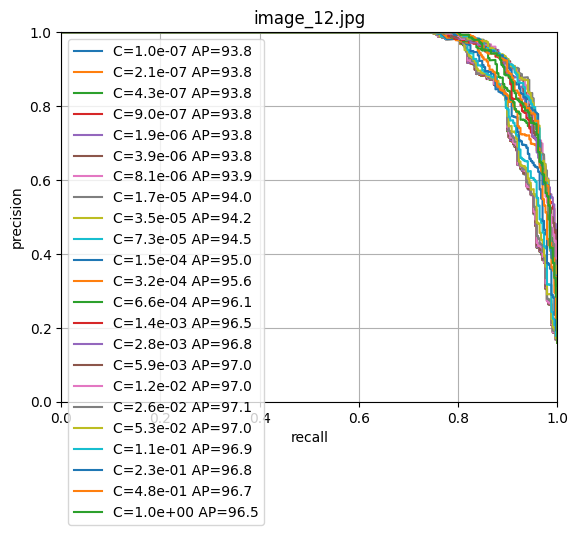

validation using image_13.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

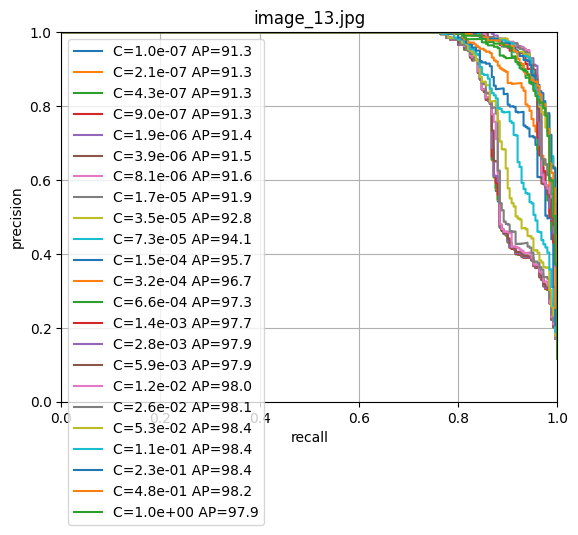

validation using image_14.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

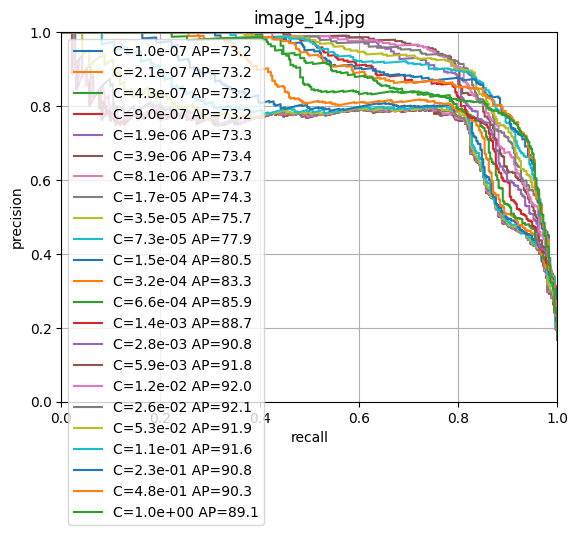

validation using image_15.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

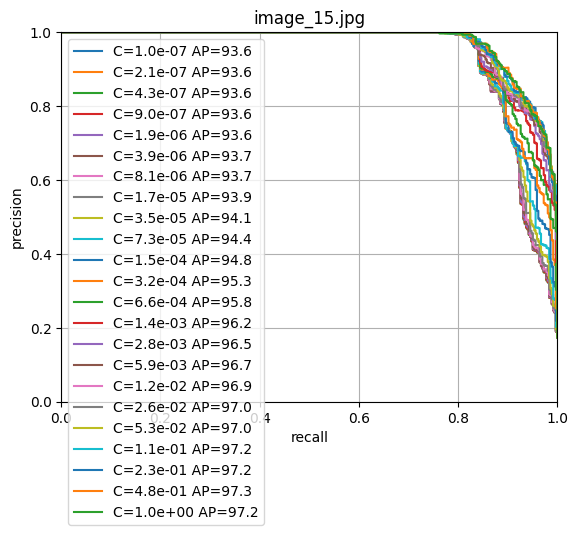

validation using image_16.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

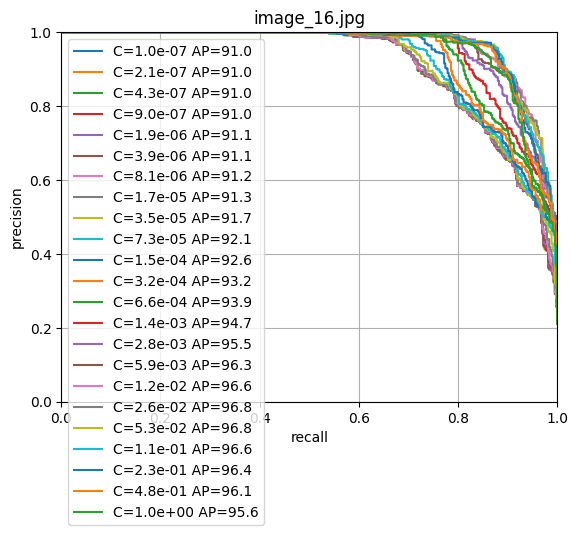

validation using image_17.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

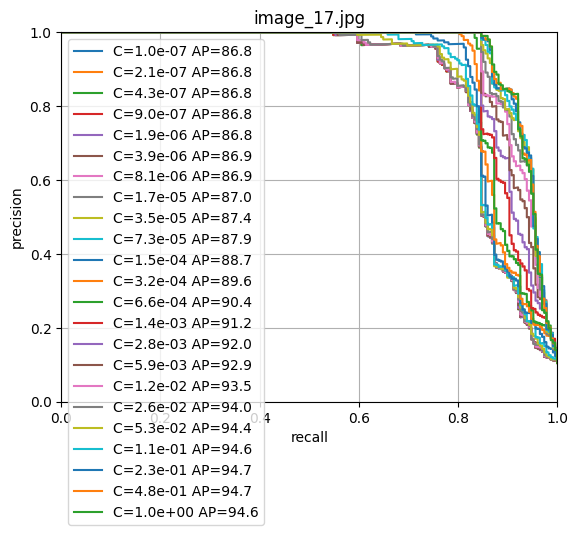

validation using image_18.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

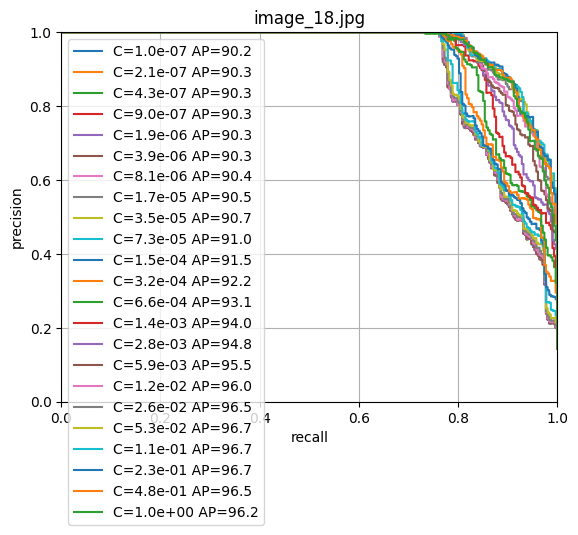

validation using image_19.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

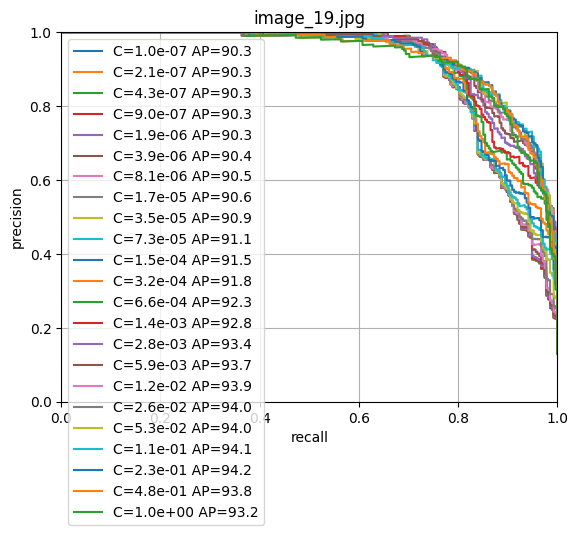

validation using image_20.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

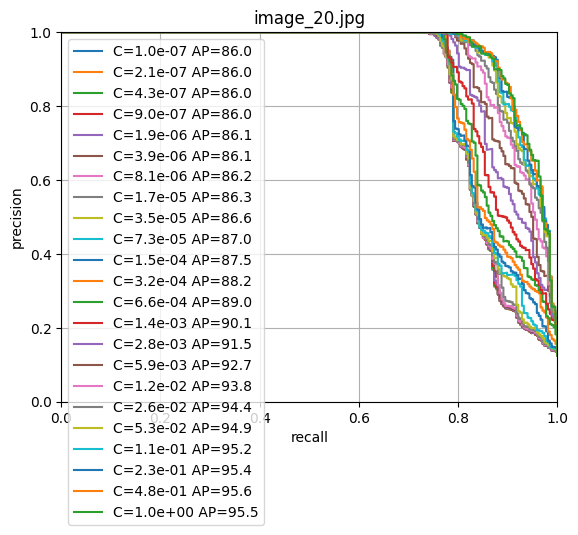

validation using image_21.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

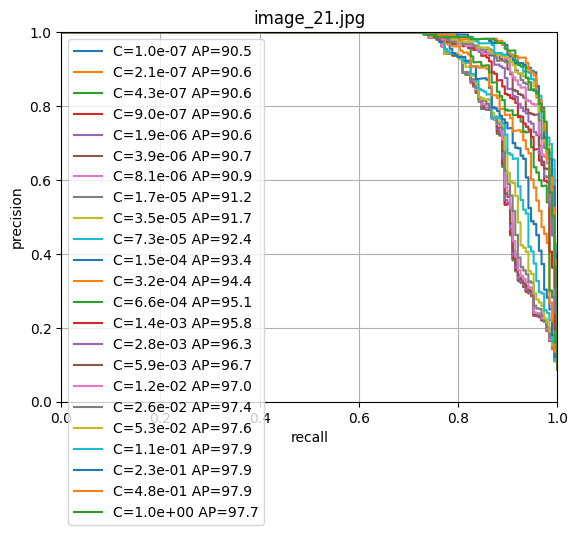

validation using image_22.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

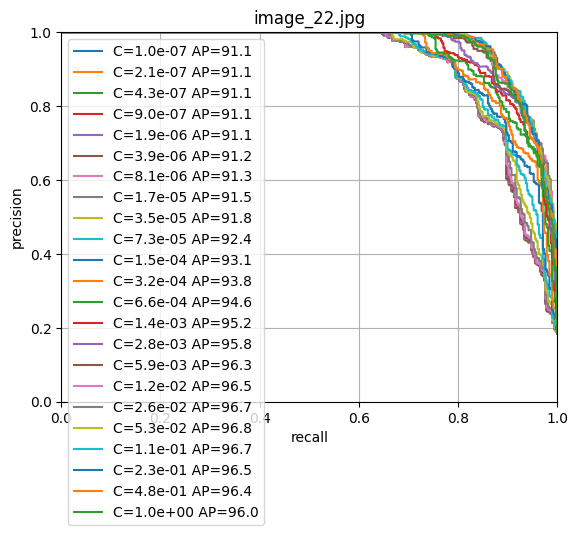

validation using image_23.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

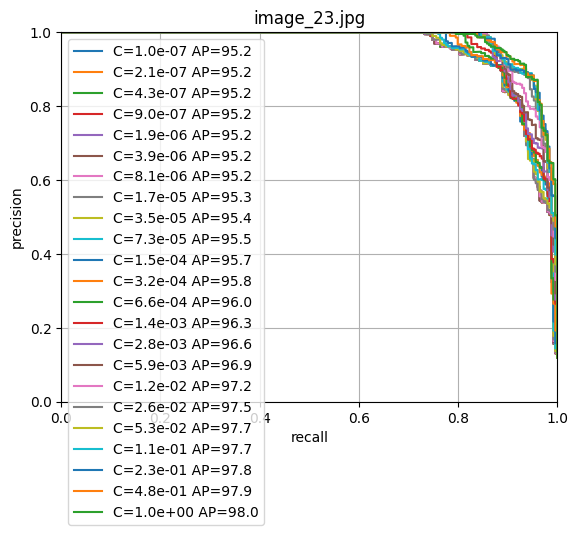

validation using image_24.jpg
training logistic regression with C=1.00e-07
training logistic regression with C=2.08e-07
training logistic regression with C=4.33e-07
training logistic regression with C=9.01e-07
training logistic regression with C=1.87e-06
training logistic regression with C=3.90e-06
training logistic regression with C=8.11e-06
training logistic regression with C=1.69e-05
training logistic regression with C=3.51e-05
training logistic regression with C=7.31e-05
training logistic regression with C=1.52e-04
training logistic regression with C=3.16e-04
training logistic regression with C=6.58e-04
training logistic regression with C=1.37e-03
training logistic regression with C=2.85e-03
training logistic regression with C=5.93e-03
training logistic regression with C=1.23e-02
training logistic regression with C=2.57e-02
training logistic regression with C=5.34e-02
training logistic regression with C=1.11e-01
training logistic regression with C=2.31e-01
training logistic regress

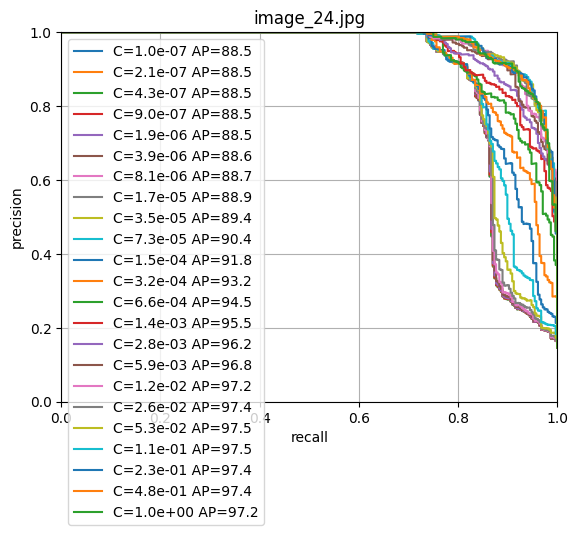

In [12]:
# determine an optimal value for the C-coeff of the logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
cs = np.logspace(-7, 0, 23)
scores = np.zeros((n_images, len(cs)))
for i in range(n_images):
    # We use leave-one-out so train will be all but image i, val will be image i
    print('validation using image_{:02d}.jpg'.format(i+1))
    train_selection = image_index != float(i)
    fold_x = xs[train_selection].numpy()
    fold_y = (ys[train_selection] > 0).long().numpy()
    val_x = xs[~train_selection].numpy()
    val_y = (ys[~train_selection] > 0).long().numpy()

    plt.figure()
    for j, c in enumerate(cs):
        print("training logistic regression with C={:.2e}".format(c))
        clf = LogisticRegression(random_state=0, C=c, max_iter=10000).fit(fold_x, fold_y)
        output = clf.predict_proba(val_x)
        precision, recall, thresholds = precision_recall_curve(val_y, output[:, 1])
        s = average_precision_score(val_y, output[:, 1])
        scores[i, j] = s
        plt.plot(recall, precision, label='C={:.1e} AP={:.1f}'.format(c, s*100))

    plt.grid()
    plt.xlabel('recall')
    plt.title('image_{:02d}.jpg'.format(i+1))
    plt.ylabel('precision')
    plt.axis([0, 1, 0, 1])
    plt.legend()
    plt.show()

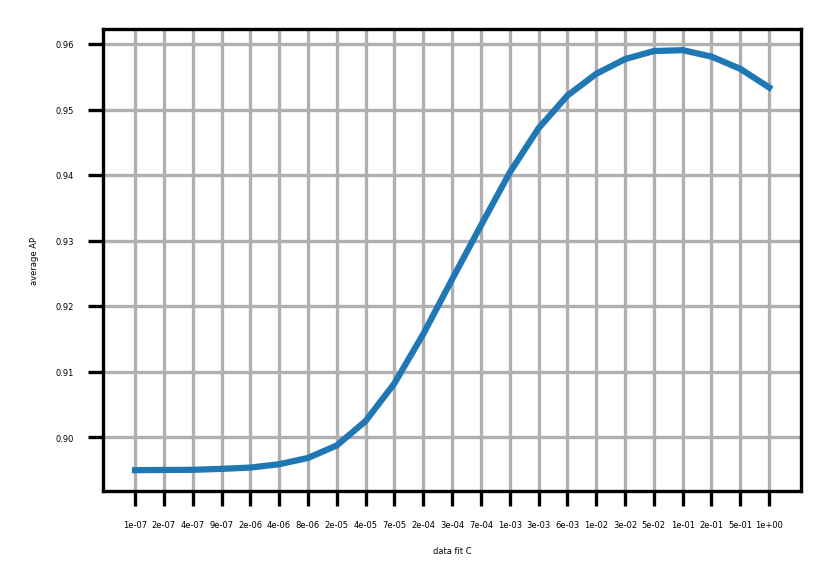

In [13]:
# find an optimal C, with the graphical support
plt.figure(figsize=(3, 2), dpi=300)
plt.rcParams.update({
    "xtick.labelsize": 2,
    "ytick.labelsize": 2,
    "axes.labelsize": 2,
})
plt.plot(scores.mean(axis=0))
plt.xticks(np.arange(len(cs)), ["{:.0e}".format(c) for c in cs])
plt.xlabel('data fit C')
plt.ylabel('average AP')
plt.grid()
plt.show()

In [14]:
#Retraining with the optimal regularization
#Given the above, we seem to have a winner: C=0.053 (take 0.05). Let's now train a model using this optimal data-fit value.
clf = LogisticRegression(random_state=0, C=0.05, max_iter=100000, verbose=2).fit(xs.numpy(), (ys > 0).long().numpy())

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.2s finished


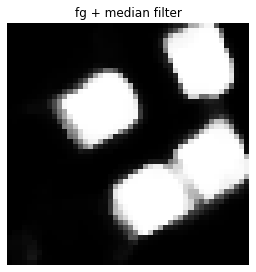

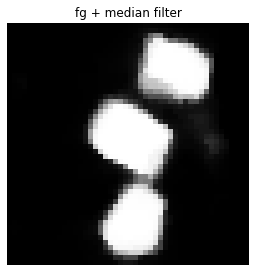

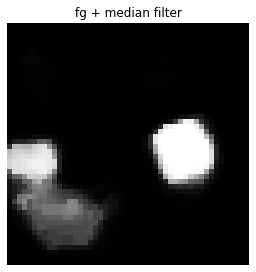

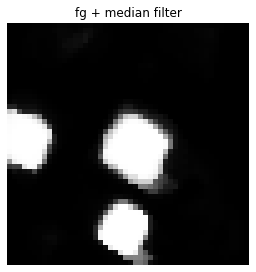

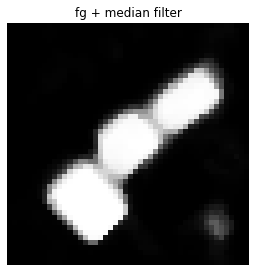

In [16]:
test_image_dir = DPATH+"/test-images/"
test_label_dir = DPATH+"/test-labels/"

for img in sorted(glob.glob("*.png",root_dir=test_image_dir)):
#    print(member)
  test_image = Image.open(test_image_dir+str(img)).convert("RGB")
  test_image_resized = resize_transform(test_image)
  test_image_normalized = TF.normalize(test_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
  with torch.inference_mode():
      with torch.autocast(device_type='cuda', dtype=torch.float32):
          feats = model.get_intermediate_layers(test_image_normalized.unsqueeze(0).cuda(), n=range(n_layers), reshape=True, norm=True)
          x = feats[-1].squeeze().detach().cpu()
          dim = x.shape[0]
          x = x.view(dim, -1).permute(1, 0)

  h_patches, w_patches = [int(d / PATCH_SIZE) for d in test_image_resized.shape[1:]]

  fg_score = clf.predict_proba(x)[:, 1].reshape(h_patches, w_patches)
  # gives nice foreground
  fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))
  # gives median-filtered foreground of small size but with all features

  plt.figure(figsize=(4.36, 4.36), dpi=72)
  # want to have 256x256 in the output with 72 dpi, as in the given labels
  plt.axis('off')
  plt.imshow(fg_score_mf,cmap='gray')
  plt.savefig(test_label_dir+str(img), bbox_inches='tight')
  plt.title('fg + median filter')
  plt.show()

In [17]:
#Saving the Model for future use
#save_root = DPATH 
model_path = os.path.join(DPATH, "fg_classifier_dida.pkl")
with open(model_path, "wb") as f:
  pickle.dump(clf, f)